In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import learning_curve
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV

In [76]:
bike_data = pd.read_csv('/kaggle/input/ml-assignment8/SeoulBikeData.csv', encoding='ISO-8859-1')

In [78]:
bike_data.head(), bike_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

(         Date  Rented Bike Count  Hour  Temperature(°C)  Humidity(%)  \
 0  01/12/2017                254     0             -5.2           37   
 1  01/12/2017                204     1             -5.5           38   
 2  01/12/2017                173     2             -6.0           39   
 3  01/12/2017                107     3             -6.2           40   
 4  01/12/2017                 78     4             -6.0           36   
 
    Wind speed (m/s)  Visibility (10m)  Dew point temperature(°C)  \
 0               2.2              2000                      -17.6   
 1               0.8              2000                      -17.6   
 2               1.0              2000                      -17.7   
 3               0.9              2000                      -17.6   
 4               2.3              2000                      -18.6   
 
    Solar Radiation (MJ/m2)  Rainfall(mm)  Snowfall (cm) Seasons     Holiday  \
 0                      0.0           0.0            0.0  Winter

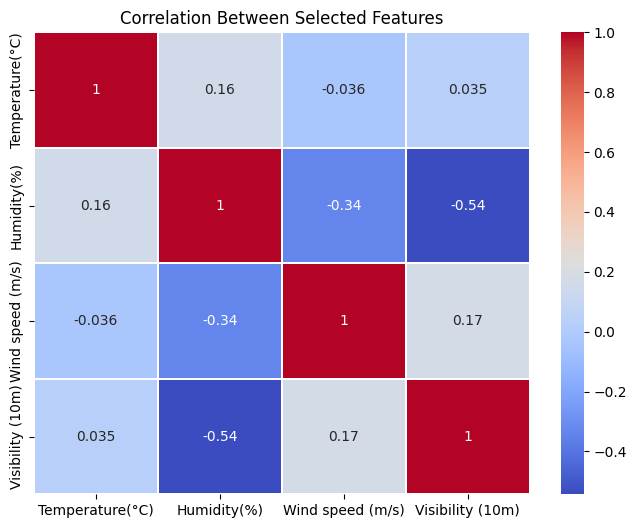

In [79]:
corr_features = ['Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)']
corr_with_demand_features = ['Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Rented Bike Count']
plt.figure(figsize=(8, 6))
sns.heatmap(bike_data[corr_features].corr(), annot=True, cmap='coolwarm', linewidths=0.1)
plt.title("Correlation Between Selected Features")
plt.show()

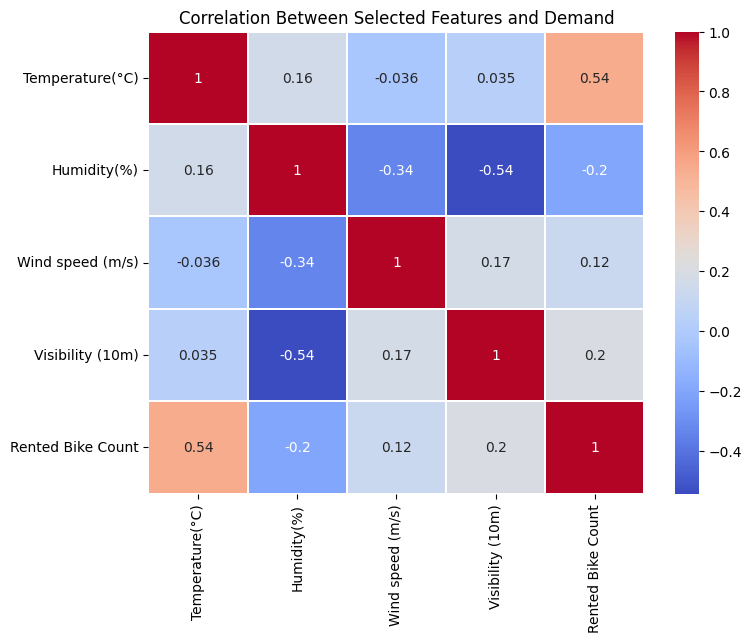

In [80]:
corr_with_demand_features = ['Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Rented Bike Count']
plt.figure(figsize=(8, 6))
sns.heatmap(bike_data[corr_with_demand_features].corr(), annot=True, cmap='coolwarm', linewidths=0.1)
plt.title("Correlation Between Selected Features and Demand")
plt.show()

In [ ]:
'The first heatmap shows the correlation between selected weather features (Temperature, Humidity, Wind Speed, Visibility).
'The second heatmap includes the target feature (Rented Bike Count) to understand how each weather feature relates to bike rental demand.


In [81]:
X = bike_data[corr_with_demand_features].drop(columns=['Rented Bike Count'])
y = bike_data['Rented Bike Count']
X_train, X_val_test, y_train, y_val_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, test_size=0.5, random_state=42)

In [ ]:
'''Temperature likely has a positive correlation with bike rentals, therefore demand may increase with warmer weather.
Humidity, wind speed, and visibility show weaker correlations, suggesting they might be less influential predictors individually

In [82]:
from sklearn.metrics import mean_absolute_error, r2_score
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
lin_mse = mean_squared_error(y_test, y_pred)
print(f'Linear Regression MSE: {lin_mse:.2f}')
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
rf_mse = mean_squared_error(y_test, y_pred)
print(f'Random Forest Regression MSE: {rf_mse:.2f}')

y_pred_lin = lin_model.predict(X_test)
mae_lin = mean_absolute_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)
print('Linear Regression MAE: %.2f' % mae_lin)
print('Linear Regression R-squared: %.2f' % r2_lin)
y_pred_rf = rf_model.predict(X_test)  
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print('Random Forest Regression MAE: %.2f' % mae_rf)
print('Random Forest Regression R-squared: %.2f' % r2_rf)


Linear Regression MSE: 228886.24
Random Forest Regression MSE: 203276.51
Linear Regression MAE: 354.62
Linear Regression R-squared: 0.40
Random Forest Regression MAE: 308.93
Random Forest Regression R-squared: 0.47


In [ ]:
'With an MSE of about 203276.51, the Random Forest model performed better than Linear Regression, likely due to its ability to capture non-linear relationships.
'The Random Forest model has a lower MAE (308.93) compared to the Linear Regression model (354.62). This indicates that, on average, the Random Forest predictions are closer to the actual values than those of the Linear Regression model.
'The R² score for the Random Forest model is 0.47, while for the Linear Regression model, it’s 0.40. R² represents the proportion of variance in the target variable i.e Rented Bike Count
'A higher R² suggests that the Random Forest model better captures the relationship between the input features and the target variable i.e Rented Bike Count 

In [ ]:
'Overall, the Random Forest model performs better than the Linear Regression model on all metrics which suggests that it is more effective at modeling the data in this case.
'This difference in performance could be due to the Random Forest model’s ability to capture non-linear relationships, while Linear Regression only models linear relationships.'

            Feature  Importance
0   Temperature(°C)    0.472736
1       Humidity(%)    0.266617
2  Wind speed (m/s)    0.133611
3  Visibility (10m)    0.127036


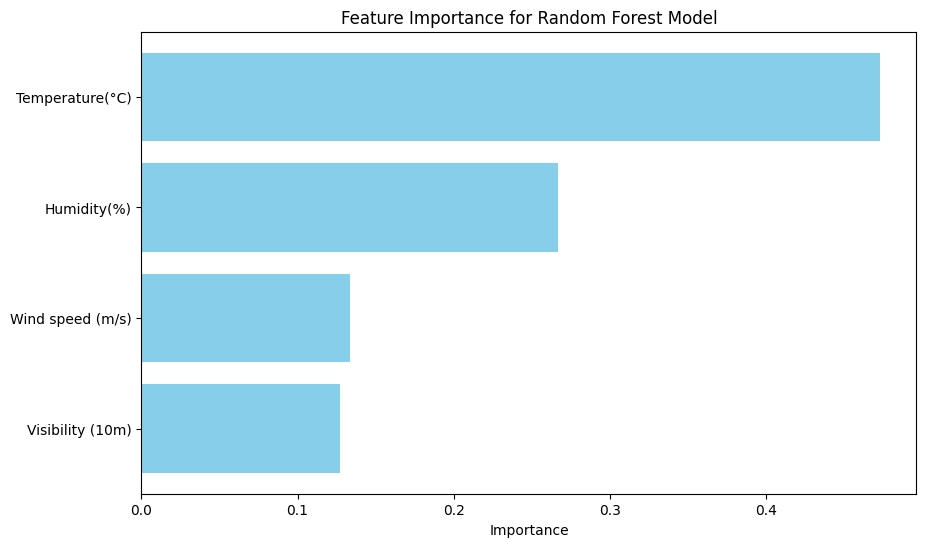

In [83]:
feature_importances = rf_model.feature_importances_
feature_names = X.columns
importances_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importances_df = importances_df.sort_values(by='Importance', ascending=False)
print(importances_df)
plt.figure(figsize=(10, 6))
plt.barh(importances_df['Feature'], importances_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importance for Random Forest Model')
plt.gca().invert_yaxis()
plt.show()

In [85]:
lin_val_pred = lin_model.predict(X_val)
lin_val_mse = mean_squared_error(y_val, lin_val_pred)
print(f'Linear Regression Validation MSE: {lin_val_mse:.2f}')
rf_val_pred = rf_model.predict(X_val)
rf_val_mse = mean_squared_error(y_val, rf_val_pred)
print(f'Random Forest Validation MSE: {rf_val_mse:.2f}')

Linear Regression Validation MSE: 280628.34
Random Forest Validation MSE: 235578.16


In [ ]:
'The Random Forest model outperforms the Linear Regression model on the validation set
'The Random Forest’s ability to reduce error on the validation set could be due to the ensemble nature of the model, which averages predictions from multiple trees, thereby reducing variance

In [60]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best Validation MSE (Random Forest):", -grid_search.best_score_)



param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validated MSE: ", -grid_search.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Best Validation MSE (Random Forest): 206976.54083502069


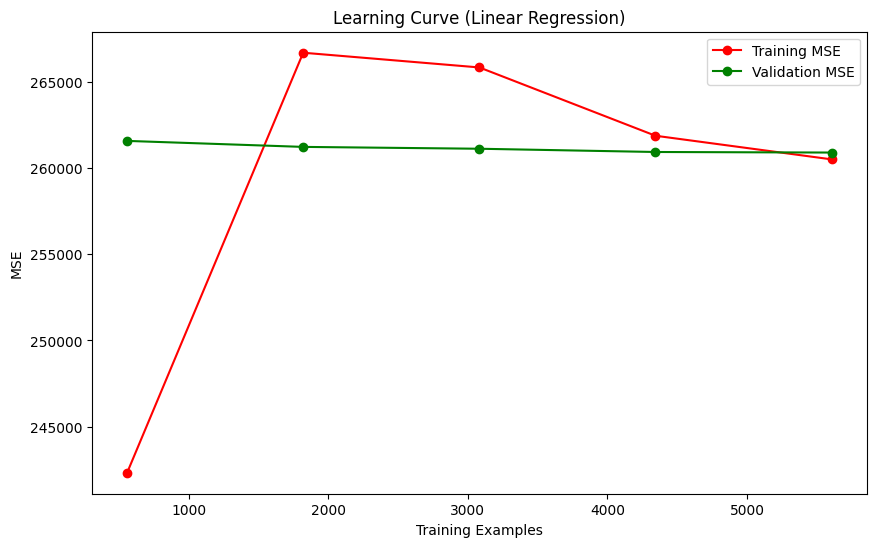

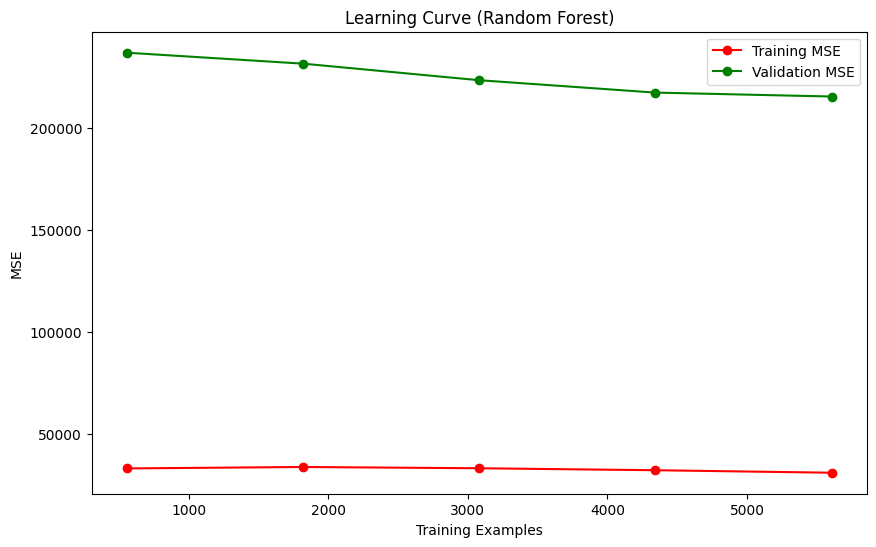

In [61]:
def plot_learning_curve(estimator, title, X, y, cv=None, scoring="neg_mean_squared_error"):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=cv, scoring=scoring, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5)
    )
    train_scores_mean = -train_scores.mean(axis=1)
    val_scores_mean = -val_scores.mean(axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training MSE")
    plt.plot(train_sizes, val_scores_mean, 'o-', color="g", label="Validation MSE")
    plt.xlabel("Training Examples")
    plt.ylabel("MSE")
    plt.title(title)
    plt.legend(loc="best")
    plt.show()
plot_learning_curve(lin_model, "Learning Curve (Linear Regression)", X_train, y_train, cv=5)
plot_learning_curve(rf_model, "Learning Curve (Random Forest)", X_train, y_train, cv=5)


In [ ]:
'The Random Forest model shows better performance and benefits from larger training sizes, indicating it is a better choice for this problem.'

In [87]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# Create polynomial features up to degree 2 (or higher if needed)
degree = 2
poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())

# Fit the model
poly_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = poly_model.predict(X_val)
mse = mean_squared_error(y_val, y_pred)
print("Validation MSE with polynomial features:", mse)


Validation MSE with polynomial features: 266221.9833076417


In [ ]:
'This MSE value is similar to or slightly higher than the validation MSE from the plain Linear Regression model in your learning curve

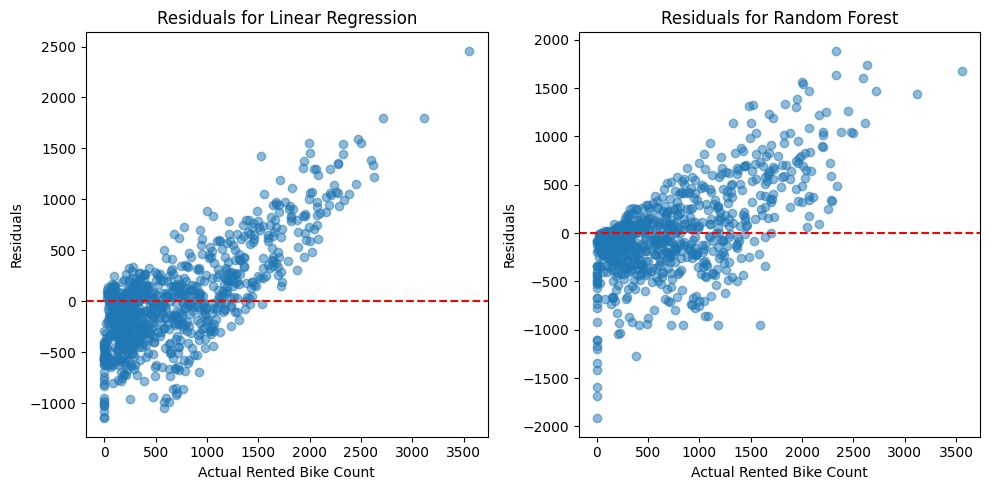

In [86]:
lin_residuals = y_test - lin_model.predict(X_test)
rf_residuals = y_test - rf_model.predict(X_test)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test, lin_residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Actual Rented Bike Count")
plt.ylabel("Residuals")
plt.title("Residuals for Linear Regression")

plt.subplot(1, 2, 2)
plt.scatter(y_test, rf_residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Actual Rented Bike Count")
plt.ylabel("Residuals")
plt.title("Residuals for Random Forest")

plt.tight_layout()
plt.show()


In [ ]:
'The residuals show a noticeable pattern. As the actual rented bike count increases, the residuals also increase, indicating that the Linear Regression model tends to underestimate the bike count for larger values.
'The residuals for the Random Forest model are more evenly distributed around the zero line with less obvious patterns
'Linear Regression shows systematic underestimation for larger bike counts, indicating it struggles with non-linear patterns in the data.
'Random Forest performs better, with more balanced residuals and fewer systematic errors.